In [2]:
import numpy as np
import sympy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting, express
from scipy.optimize import root

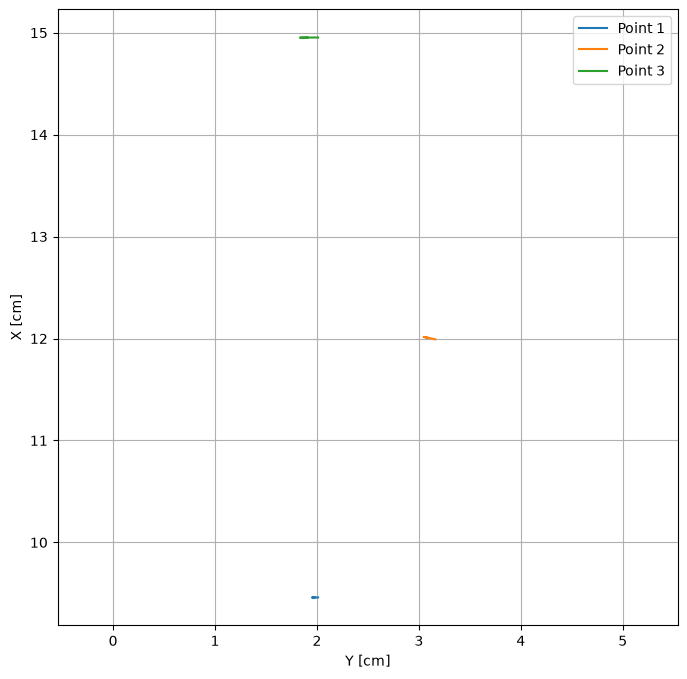

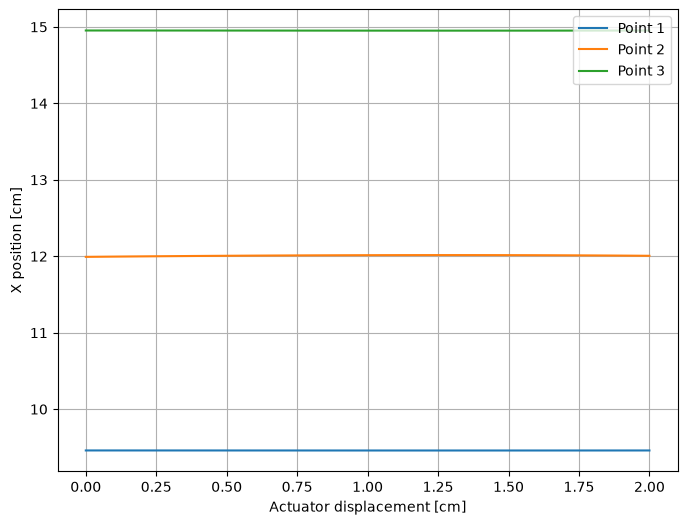

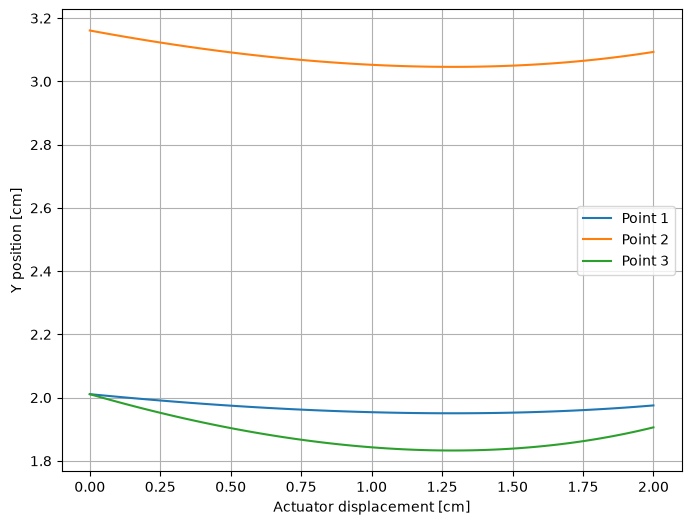

In [ ]:
import numpy as np
import sympy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting, express
from scipy.optimize import root

theta1, theta2, x = dynamicsymbols('theta1 theta2 x')
l1, l2, l3 = sympy.symbols('l1 l2 l3')

#lengths
L1 = 9.492 / 10
L2 = np.sqrt(56.19**2 + 23.24**2) / 10
L3 = np.sqrt(44.44**2 + 58.36**2) / 10

#reference frame
N = ReferenceFrame('N')
A = N.orientnew('A','Axis',(theta1, N.z))
B = N.orientnew('B','Axis',(theta2 - sympy.pi / 2, N.z))

#vectores 
r1 = x * N.x + l1 * N.y
r2 = l2 * A.x
r3 = l3 * B.x
r4 = (-6.637) * N.x - 2.011 * N.y

#loop
ROC = r1 + r2 + r3 + r4

#Equations
eq_x = sympy.simplify(ROC.dot(N.x))
eq_y = sympy.simplify(ROC.dot(N.y))

#pasar a python functions
f_x = sympy.lambdify(
    (theta1, theta2, x, l1, l2, l3),
    eq_x,
    'numpy'
)

f_y = sympy.lambdify(
    (theta1, theta2, x, l1, l2, l3),
    eq_y,
    'numpy'
)

#resolver angles:
def find_angles(x_value, guess):

    def equations(q):

        t1, t2 = q

        return [
            f_x(t1, t2, x_value, L1, L2, L3),
            f_y(t1, t2, x_value, L1, L2, L3)
        ]

    sol = root(equations, guess)

    if not sol.success:
        return None

    return sol.x

# desplazamiento actaudor
x_values = np.linspace(0, 2, 100)

theta1_values = []
theta2_values = []

guess = [np.deg2rad(80), np.deg2rad(50)]

for x_value in x_values:

    solution = find_angles(x_value, guess)

    if solution is not None:
        theta1_values.append(solution[0])
        theta2_values.append(solution[1])

        # Use the previous solution as the next initial guess
        guess = solution

theta1 = np.rad2deg(theta1_values)
theta2 = np.rad2deg(theta2_values)

theta1_rad = np.array(theta1_values)
theta2_rad = np.array(theta2_values)

# r2 components
r2_x = L2 * np.cos(theta1_rad)
r2_y = L2 * np.sin(theta1_rad)

# r3 angle in the global reference frame
r3_angle = theta2_rad - np.pi / 2

# r3 components
r3_x = L3 * np.cos(r3_angle)
r3_y = L3 * np.sin(r3_angle)

# Endpoint of r3
end_r3_x = x_values + r2_x + r3_x
end_r3_y = L1 + r2_y + r3_y

# points of interest 

l31 = 2.823
l32 = 5.355
l322 = 1.15
l33 = 8.316

# Point 1
P1_dx = l31 * np.cos(delta_theta)
P1_dy = l31 * np.sin(delta_theta)

P1_x = end_r3_x + P1_dx
P1_y = end_r3_y + P1_dy


# Point 2
P2_dx = l32 * np.cos(delta_theta) - l322 * np.sin(delta_theta)
P2_dy = l32 * np.sin(delta_theta) + l322 * np.cos(delta_theta)

P2_x = end_r3_x + P2_dx
P2_y = end_r3_y + P2_dy


# Point 3
P3_dx = l33 * np.cos(delta_theta)
P3_dy = l33 * np.sin(delta_theta)

P3_x = end_r3_x + P3_dx
P3_y = end_r3_y + P3_dy

#Graph 1
plt.figure(figsize=(8, 8))

plt.plot(P1_y, P1_x, label='Point 1')
plt.plot(P2_y, P2_x, label='Point 2')
plt.plot(P3_y, P3_x, label='Point 3')

plt.xlabel('Y [cm]')
plt.ylabel('X [cm]')

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

#Graph 2
plt.figure(figsize=(8, 6))

plt.plot(x_values, P1_x, label='Point 1')
plt.plot(x_values, P2_x, label='Point 2')
plt.plot(x_values, P3_x, label='Point 3')

plt.xlabel('Actuator displacement [cm]')
plt.ylabel('X position [cm]')
plt.grid(True)
plt.legend()
plt.show()

#graph 3

plt.figure(figsize=(8, 6))

plt.plot(x_values, P1_y, label='Point 1')
plt.plot(x_values, P2_y, label='Point 2')
plt.plot(x_values, P3_y, label='Point 3')

plt.xlabel('Actuator displacement [cm]')
plt.ylabel('Y position [cm]')
plt.grid(True)
plt.legend()
plt.show()